# Análisis y Procesamiento de Señales

## Trabajo Práctico N°4

### Ferreyra Valentina

### Introducción

En este trabajo se analizará el comportamiento de distintos estimadores de **amplitud y frecuencia** aplicados a una señal senoidal afectada por ruido. Para ello se generarán múltiples realizaciones de una señal cuya frecuencia presenta una pequeña variación aleatoria alrededor de una frecuencia central, y se evaluará su representación en el dominio frecuencial mediante la Transformada Discreta de Fourier (DFT).

El análisis se realizará utilizando diferentes ventanas: **rectangular, Flattop, Blackman-Harris y Hann**, con el objetivo de observar cómo cada una afecta la estimación de la amplitud y de la frecuencia de la señal. Para comparar su desempeño se analizarán los histogramas obtenidos para distintas relaciones señal-ruido (SNR) y posteriormente se calcularán el **sesgo y la varianza** de cada estimador.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

In [2]:
a0 = np.sqrt(2) 
N = 1000
fs = 1000

In [3]:
f_r = np.random.uniform(-2,2,200)

omega0 = np.pi/2

### Análisis para SNR = 10 dB

In [4]:
SNR = 10 
Ps = 1

Pr = Ps / (10**(SNR/10))

sigma = np.sqrt(Pr)

n_a = np.random.normal(0,sigma,(N,200))

En esta parte del codigo se define la variación aleatoria de frecuencia mediante $f_r$, que permite que cada una de las realizaciones tenga una frecuencia ligeramente distinta alrededor de la frecuencia central. La potencia de la señal es $P_s=1\,W$ como pide la consigna, por lo que para una senoide se utiliza $a_0=\sqrt{2}$. A partir de la SNR, siguiendo la forma $ SNR=10\log_{10}\left(\frac{P_s}{P_r}\right) $se calcula la potencia del ruido $P_r$, y como para el ruido gaussiano de media cero se cumple que $P_r=\sigma^2$, se obtiene el desvío estándar como $\sigma=\sqrt{P_r}$. Finalmente, $n_a$ representa el ruido gaussiano que se agrega a cada una de las muestras de las 200 realizaciones.

In [5]:
def mi_funcion_sen():
    
    omega1 = omega0 + f_r*(2*np.pi/N)
    
    omega1 = omega1.reshape(1,200)

    n = np.arange(N).reshape(N,1)
    
    xx = a0 * np.sin(omega1*n) + n_a
    
    return (n,xx)

n,xx = mi_funcion_sen()

Como se necesitan 200 realizaciones con frecuencias diferentes, se genera $\Omega_1$ con 200 valores y se lo organiza como un vector fila. Por otro lado, $n$ contiene las $N=1000$ muestras y se organiza como un vector columna. Al multiplicar $n$ por $\Omega_1$, se combinan ambos vectores y genera una matriz de $1000\times200$, donde cada columna corresponde a una realización de 1000 muestras con una frecuencia aleatoria diferente. Finalmente, sobre esta matriz se genera la señal senoidal y se agrega el ruido correspondiente.

In [6]:
frecuencia = np.arange(N//2) * fs/N

xx_fft = 1/N * np.fft.fft(xx,axis=0) 

XX_mod = np.abs(xx_fft)

espectro = (XX_mod)**2
dens_espc = 10*np.log10(2*(espectro[:N//2]))

A continuación calculo la FFT de las 200 realizaciones, trabajando sobre el eje de frecuencia en Hz y considerando únicamente la mitad positiva del espectro. A partir del módulo de la FFT se obtiene el espectro de potencia y luego se lo expresa en decibeles mediante $10\log_{10}(\cdot)$, lo que permite visualizar con mayor claridad las diferencias de potencia entre las componentes espectrales.

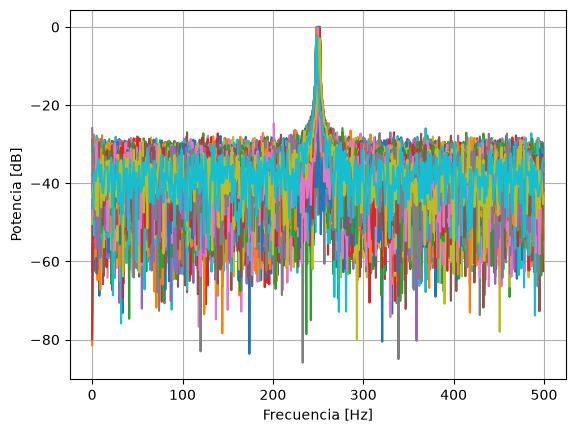

In [7]:
plt.figure()
plt.plot(frecuencia, dens_espc)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.grid()
plt.show()

En el gráfico se observan los espectros correspondientes a las 200 realizaciones de la señal, cada una formada por 1000 muestras y con una frecuencia ligeramente diferente debido a la variación aleatoria $f_r$. Los picos se concentran alrededor de la frecuencia central de $250\,Hz$, mientras que el resto del espectro corresponde principalmente al ruido agregado a cada realización.

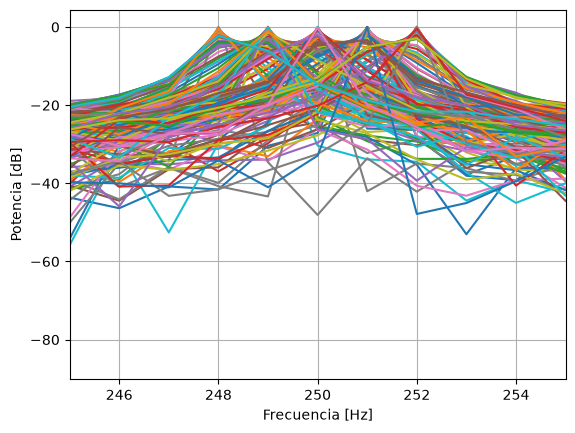

In [8]:
plt.figure()
plt.plot(frecuencia, dens_espc)
plt.xlim(245,255)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.grid()
plt.show()

Al realizar un acercamiento alrededor del pico podemos ver que las distintas realizaciones se encuentran distribuidas alrededor de una frecuencia central de $250\,Hz$. Este valor viene de $\Omega_0=\pi/2$, que al expresarse en Hz corresponde a $f_0=\frac{\Omega_0}{2\pi}f_s=250\,Hz.$

A su vez, la variable aleatoria $f_r$ produce pequeños desplazamientos alrededor de esta frecuencia central, por lo que los picos de las 200 realizaciones no se encuentran exactamente en el mismo punto.

##### a.

##### Ventana rectangular

En este primer caso se utiliza una ventana rectangular, que equivale a no aplicar ninguna modificación sobre la señal, ya que $w[n]=1$ para todas las muestras. Por lo tanto, la FFT se calcula directamente sobre cada una de las 200 realizaciones originales. Esta ventana se toma como referencia para comparar luego con Flattop, Blackman-Harris y Hann. Como las frecuencias de las realizaciones pueden no coincidir exactamente con un bin de la FFT, con la ventana rectangular puede aparecer desparramo espectral, afectando principalmente la estimación de la amplitud.

In [9]:
a1 = 2*XX_mod [N//4,:]

maxi = np.argmax(XX_mod[:N//2, :], axis = 0) 

frec_est = maxi * fs/N

Para estimar la amplitud se toma el módulo de la FFT en el bin correspondiente a la frecuencia central. Como $\Omega_0=\pi/2$, esta frecuencia se encuentra en el bin $N/4=250$. Se multiplica por 2 debido a que, al trabajar con una señal real, la amplitud de la senoide se encuentra repartida entre las componentes positiva y negativa del espectro.

Para estimar la frecuencia, `np.argmax` busca en cada una de las 200 realizaciones el índice del bin donde el módulo de la FFT alcanza su valor máximo. La búsqueda se realiza únicamente sobre la mitad positiva del espectro. Finalmente, este índice se convierte a frecuencia en Hz utilizando la resolución frecuencial $ \Delta f=\frac{f_s}{N} $ por lo que la frecuencia estimada se obtiene como $f_{\text{est}}=k_{\max}\,\Delta f$.

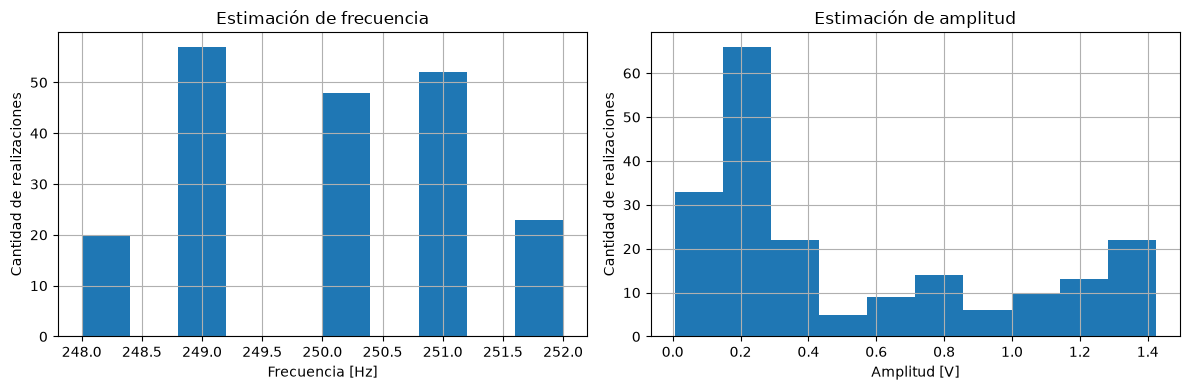

In [20]:
plt.figure(figsize=(12,4))

# Frecuencia
plt.subplot(1,2,1)
plt.hist(frec_est)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de frecuencia')
plt.grid()

# Amplitud
plt.subplot(1,2,2)
plt.hist(a1)
plt.xlabel('Amplitud [V]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de amplitud')
plt.grid()

plt.tight_layout()
plt.show()

En el histograma de frecuencia se observa que las estimaciones se concentran entre $248$ y $252\,Hz$, alrededor de la frecuencia central de $250\,Hz$. Esto ocurre porque $f_r$ introduce una variación aleatoria entre $-2$ y $2\,Hz$. Además, como la resolución frecuencial es $\Delta f=f_s/N=1\,Hz$, el estimador solo puede seleccionar los bins $248$, $249$, $250$, $251$ y $252\,Hz$. Los bins de los extremos presentan menos realizaciones debido a que abarcan un intervalo menor de valores de $f_r$ que los bins centrales.

En el histograma de amplitud se observa una mayor dispersión. Esto sucede porque el estimador mide siempre la amplitud en el bin correspondiente a $250\,Hz$, mientras que la frecuencia real de cada realización puede encontrarse desplazada respecto de este valor. Cuando la frecuencia está próxima a $250\,Hz$, la amplitud estimada se aproxima al valor real $a_0=\sqrt{2}$, mientras que al alejarse se produce desparramo espectral y disminuye la amplitud observada en ese bin. Este comportamiento muestra que la ventana rectangular es sensible al desplazamiento de la frecuencia respecto de los bins de la FFT.

##### Ventana Flattop

A continuación se aplica una ventana Flattop a cada una de las 200 realizaciones. Esta ventana modifica las muestras de la señal antes de calcular la FFT y está diseñada para obtener una estimación de amplitud más estable cuando la frecuencia de la señal no coincide exactamente con un bin de la transformada. Para aplicarla a todas las realizaciones, la ventana se organiza como un vector columna de $N=1000$ muestras y se multiplica por la matriz de señales.

In [15]:
ventana = windows.flattop(N)

ventana = ventana.reshape(N,1)

xx_flat = xx * ventana

In [17]:
xx_fft_flat = 1/N * np.fft.fft(xx_flat, axis=0)

XX_mod_flat = np.abs(xx_fft_flat)

Luego de aplicar la ventana Flattop, se calcula la FFT de cada una de las 200 realizaciones, trabajando nuevamente por columnas. A partir de esta transformada se obtiene su módulo, tal como venimos haciendo, que representa la magnitud de cada componente frecuencial. El eje de frecuencias es el mismo definido anteriormente, ya que $N$ y $f_s$ no cambiaron.

In [18]:
a1_flat = 2*XX_mod_flat [N//4,:]

maxi_flat = np.argmax(XX_mod_flat[:N//2, :], axis = 0) 

frec_est_flat = maxi_flat * fs/N

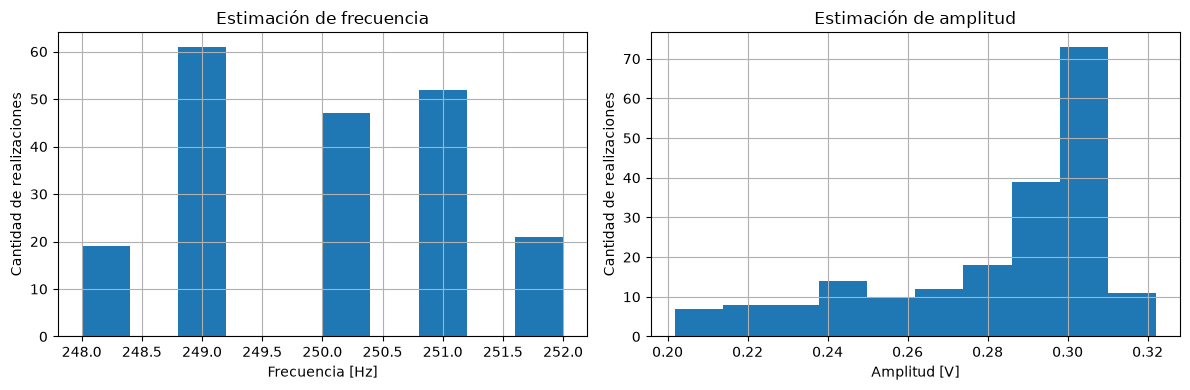

In [19]:
plt.figure(figsize=(12,4))

# Frecuencia
plt.subplot(1,2,1)
plt.hist(frec_est_flat)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de frecuencia')
plt.grid()

# Amplitud
plt.subplot(1,2,2)
plt.hist(a1_flat)
plt.xlabel('Amplitud [V]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de amplitud')
plt.grid()

plt.tight_layout()
plt.show()

En el histograma de frecuencia se observa nuevamente que las estimaciones se encuentran entre $248$ y $252\,Hz$ y centradas alrededor de $250\,Hz$. Esto se debe a la variación aleatoria introducida por $f_r$ y a que la resolución frecuencial es de $1\,Hz$, por lo que el estimador selecciona alguno de esos bins. 

Mirando en cambio el grafico de amplitud, a diferencia de la ventana rectangular, las estimaciones se encuentran mucho más concentradas, principalmente alrededor de $0.30\,V$, lo que indica una menor dispersión y, por lo tanto, una menor varianza del estimador. El valor se encuentra alejado de la amplitud real $a_0=\sqrt{2}$. Sin embargo, puede observarse que la amplitud estimada varía mucho menos entre las distintas realizaciones.

##### Ventana Blackman-Harris

A continuación se aplica la ventana Blackman-Harris a las 200 realizaciones. Esta ventana atenúa fuertemente los extremos de la señal y se caracteriza por reducir el nivel de los lóbulos laterales del espectro, lo que ayuda a disminuir el desparramo espectral. Luego, al igual que con Flattop, la ventana se organiza como un vector columna y se multiplica por la matriz de señales para aplicarla a todas las realizaciones.

Para las ventana Blackman-Harris y la Hann se sigue el mismo procedimiento utilizado anteriormente: se aplica la ventana sobre cada una de las 200 realizaciones, se calcula la FFT, se obtiene su módulo y finalmente se estiman la amplitud y la frecuencia. La diferencia en este caso está únicamente en la forma de la ventana utilizada y en cómo esta afecta al espectro de la señal.

In [22]:
ventana_blackmanharris = windows.blackmanharris(N)

ventana_blackmanharris = ventana_blackmanharris.reshape(N,1)

xx_blackmanharris = xx * ventana_blackmanharris

In [23]:
xx_fft_blackmanharris = 1/N * np.fft.fft(xx_blackmanharris, axis=0)

XX_mod_blackmanharris = np.abs(xx_fft_blackmanharris)

In [24]:
a1_blackmanharris = 2*XX_mod_blackmanharris [N//4,:]

maxi_blackmanharris = np.argmax(XX_mod_blackmanharris[:N//2, :], axis = 0) 

frec_est_blackmanharris = maxi_blackmanharris * fs/N

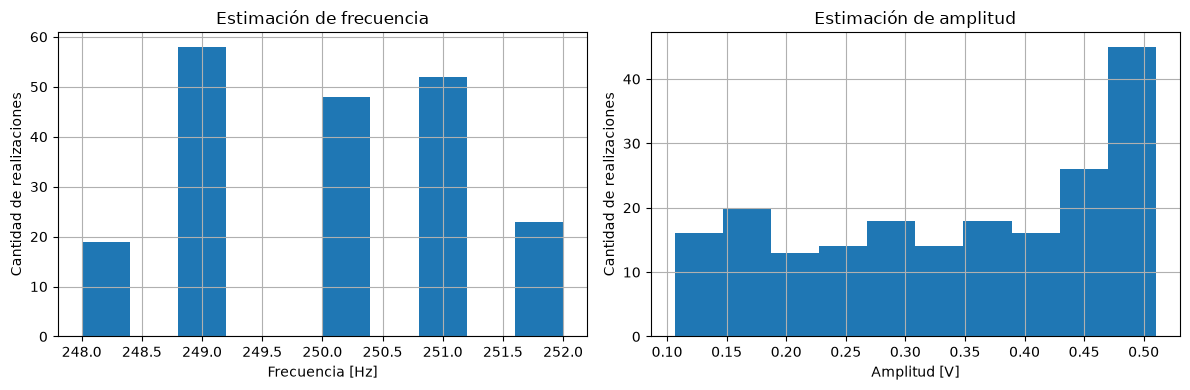

In [27]:
plt.figure(figsize=(12,4))

# Frecuencia
plt.subplot(1,2,1)
plt.hist(frec_est_blackmanharris)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de frecuencia')
plt.grid()

# Amplitud
plt.subplot(1,2,2)
plt.hist(a1_blackmanharris)
plt.xlabel('Amplitud [V]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de amplitud')
plt.grid()

plt.tight_layout()
plt.show()

En la estimación de frecuencia se mantiene un comportamiento similar a los casos anteriores: los valores se encuentran entre $248$ y $252\,Hz$ y distribuidos alrededor de la frecuencia central de $250\,Hz$. Esto indica que, para este experimento, la ventana Blackman-Harris no produce un cambio significativo en la ubicación del máximo de la FFT. En cambio, en la estimación de amplitud se observa una mayor dispersión que con Flattop, con valores aproximadamente entre $0.1$ y $0.5\,V$. Esto muestra que la amplitud estimada depende más del desplazamiento de la frecuencia respecto del bin central, aunque la ventana Blackman-Harris permite reducir el desparramo hacia los lóbulos laterales del espectro.

##### Ventana Hann

Por último, se aplica la ventana Hann, que suaviza los extremos de la señal antes de calcular la FFT y permite reducir el desparramo espectral respecto de la ventana rectangular.

In [28]:
ventana_hann = windows.hann(N)

ventana_hann = ventana_hann.reshape(N,1)

xx_hann = xx * ventana_hann

In [29]:
xx_fft_hann = 1/N * np.fft.fft(xx_hann, axis=0)

XX_mod_hann = np.abs(xx_fft_hann)

In [30]:
a1_hann = 2*XX_mod_hann [N//4,:]

maxi_hann = np.argmax(XX_mod_hann[:N//2, :], axis = 0) 

frec_est_hann = maxi_hann * fs/N

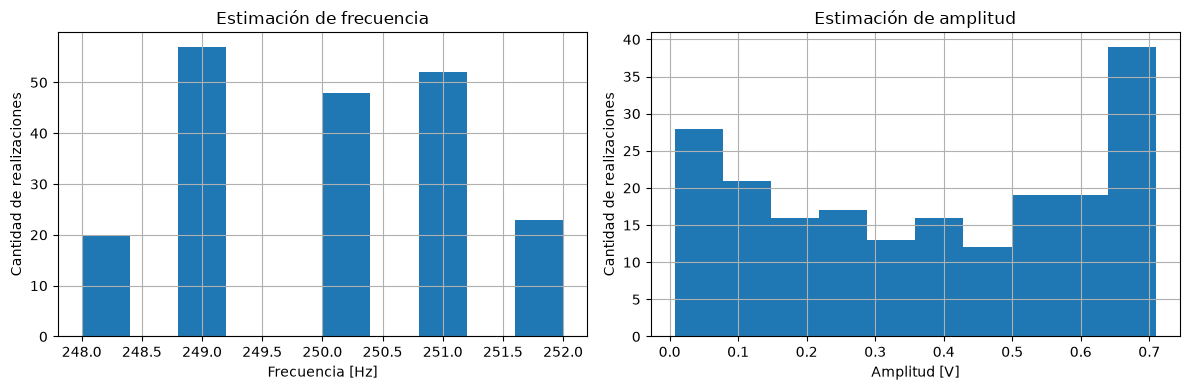

In [31]:
plt.figure(figsize=(12,4))

# Frecuencia
plt.subplot(1,2,1)
plt.hist(frec_est_hann)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de frecuencia')
plt.grid()

# Amplitud
plt.subplot(1,2,2)
plt.hist(a1_hann)
plt.xlabel('Amplitud [V]')
plt.ylabel('Cantidad de realizaciones')
plt.title('Estimación de amplitud')
plt.grid()

plt.tight_layout()
plt.show()

En la estimación de frecuencia se mantiene un comportamiento similar al observado con las demás ventanas: los valores se concentran entre $248$ y $252\,Hz$ y alrededor de la frecuencia central de $250\,Hz$, por lo que la ventana Hann no modifica significativamente la ubicación del máximo de la FFT en este experimento. En la estimación de amplitud se observa una dispersión mayor que con Flattop y menor que con la ventana rectangular, con valores distribuidos aproximadamente entre $0$ y $0.7\,V$. Esto muestra que la ventana Hann reduce parte del efecto del desparramo espectral, aunque la amplitud estimada sigue dependiendo del corrimiento de la frecuencia respecto del bin central.

En la estimación de frecuencia se mantiene un comportamiento similar al observado con las demás ventanas: los valores se concentran entre $248$ y $252\,Hz$ y alrededor de la frecuencia central de $250\,Hz$, por lo que la ventana Hann no modifica significativamente la ubicación del máximo de la FFT en este experimento. En la estimación de amplitud se observa una dispersión mayor que con Flattop y menor que con la ventana rectangular, con valores distribuidos aproximadamente entre $0$ y $0.7\,V$. Esto muestra que la ventana Hann reduce parte del efecto del desparramo espectral, aunque la amplitud estimada sigue dependiendo del corrimiento de la frecuencia respecto del bin central.

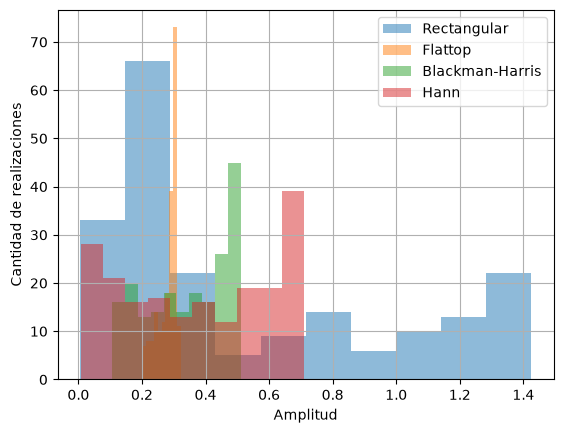

In [32]:
plt.figure()

plt.hist(a1, alpha=0.5, label='Rectangular')
plt.hist(a1_flat, alpha=0.5, label='Flattop')
plt.hist(a1_blackmanharris, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_hann, alpha=0.5, label='Hann')

plt.xlabel('Amplitud')
plt.ylabel('Cantidad de realizaciones')

plt.legend()
plt.grid()
plt.show()

Al comparar los histogramas de amplitud de las cuatro ventanas se observa claramente que cada una presenta un comportamiento diferente frente al desplazamiento aleatorio de la frecuencia. La ventana rectangular presenta la mayor dispersión, con estimaciones que van desde valores cercanos a cero hasta valores próximos a la amplitud real $a_0=\sqrt{2}$, indicando una gran sensibilidad a la posición de la frecuencia respecto de los bins de la FFT y, por lo tanto, una varianza elevada. En cambio, la ventana Flattop presenta las estimaciones mucho más concentradas, lo que indica una varianza considerablemente menor y una mayor estabilidad en la estimación de amplitud. Las ventanas Hann y Blackman-Harris muestran comportamientos intermedios, reduciendo la dispersión respecto de la rectangular pero sin alcanzar la estabilidad de Flattop. Los valores medios de las ventanas aparecen desplazados respecto de $a_0$.

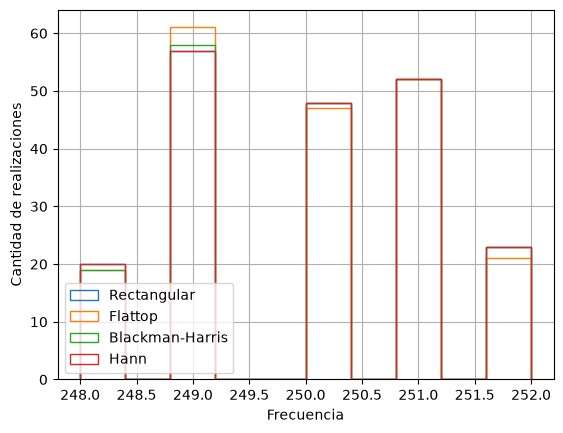

In [33]:
plt.figure()

plt.hist(frec_est, histtype='step', label='Rectangular')
plt.hist(frec_est_flat, histtype='step', label='Flattop')
plt.hist(frec_est_blackmanharris, histtype='step', label='Blackman-Harris')
plt.hist(frec_est_hann, histtype='step', label='Hann')

plt.xlabel('Frecuencia')
plt.ylabel('Cantidad de realizaciones')

plt.legend()
plt.grid()
plt.show()

Al comparar los estimadores de frecuencia de las cuatro ventanas se observa que sus histogramas se encuentran prácticamente superpuestos. Las estimaciones toman valores entre $248$ y $252\,Hz$ y se distribuyen alrededor de la frecuencia central de $250\,Hz$. Esto se debe a que $f_r$ introduce variaciones entre $-2$ y $2\,Hz$, mientras que la resolución de la FFT es $\Delta f=f_s/N=1\,Hz$, por lo que el estimador solo puede seleccionar frecuencias correspondientes a los bins $248$, $249$, $250$, $251$ y $252\,Hz$. A diferencia de lo observado en la estimación de amplitud, el tipo de ventana no produce grandes diferencias en la frecuencia estimada, ya que aunque cada ventana modifica la forma y el ancho del pico espectral, la posición de su máximo permanece prácticamente en el mismo bin. Por esta razón, no se observa en este gráfico una ventana claramente superior para la estimación de frecuencia, por lo que su desempeño se analizará con mayor precisión a partir del sesgo y la varianza.

##### b.

En esta parte se calcula, para cada una de las ventanas analizadas, la esperanza, el sesgo y la varianza del estimador de amplitud a partir de las 200 realizaciones. La esperanza se aproxima mediante la media muestral de las amplitudes estimadas, el sesgo se obtiene comparando esa media con la amplitud real $a_0=\sqrt{2}$ y permite evaluar qué tan alejado se encuentra, en promedio, el estimador del valor verdadero, mientras que la varianza mide cuánto se dispersan las distintas estimaciones respecto de su media. De esta forma se puede comparar no solo qué ventana produce valores más cercanos al valor real, sino también cuál entrega estimaciones más estables entre las diferentes realizaciones.

In [34]:
a1_esperanza = np.mean(a1)

sesgo = a1_esperanza - a0

varianza = np.mean((a1 - a1_esperanza)**2)

In [36]:
a1_flat_esperanza = np.mean(a1_flat)

sesgo_flat = a1_flat_esperanza - a0

varianza_flat = np.mean((a1_flat - a1_flat_esperanza)**2)

In [40]:
a1_blackmanharris_esperanza = np.mean(a1_blackmanharris)

sesgo_blackmanharris = a1_blackmanharris_esperanza - a0

varianza_blackmanharris = np.mean((a1_blackmanharris - a1_blackmanharris_esperanza)**2)

In [41]:
a1_hann_esperanza = np.mean(a1_hann)

sesgo_hann = a1_hann_esperanza - a0

varianza_hann = np.mean((a1_hann - a1_hann_esperanza)**2)

#### Sesgo y varianza del estimador de amplitud

| Ventana | Sesgo | Varianza |
|---|---:|---:|
| Rectangular | -0.8850959956839427 | 0.19643959790872814 |
| Flattop | -1.1320463658722626 | 0.0008460109299236101 |
| Blackman-Harris | -1.0721970065452537 | 0.01585167755798665 |
| Hann | -1.0398149491096482 | 0.05431921058817359 |

A partir de los resultados se observa que todas las ventanas presentan un sesgo negativo, lo que indica una subestimación de la amplitud real $a_0=\sqrt{2}$. La ventana rectangular presenta el sesgo de menor magnitud, mientras que Flattop presenta el mayor. En cuanto a la varianza, las diferencias son mucho más claras: Flattop presenta la menor varianza, seguida por Blackman-Harris y Hann, mientras que la ventana rectangular presenta la mayor dispersión. Esto coincide con lo observado en los histogramas, donde Flattop concentra las estimaciones en un intervalo muy reducido y la rectangular presenta valores distribuidos en un rango mucho mayor. Por lo tanto, Flattop resulta ser la ventana más estable para la estimación de amplitud frente a pequeños desplazamientos de frecuencia, mientras que la rectangular es la más sensible. Estos resultados muestran la importancia de analizar conjuntamente el sesgo y la varianza, ya que una menor dispersión no implica necesariamente un menor sesgo.

Para analizar el estimador de frecuencia se consideran primero las frecuencias reales de cada realización, dadas por $f_1=250+f_r$, ya que cada señal posee un pequeño corrimiento aleatorio respecto de la frecuencia central. La esperanza del estimador se aproxima mediante la media de las 200 frecuencias estimadas. Luego, el sesgo se calcula promediando la diferencia entre la frecuencia estimada y la frecuencia verdadera de cada realización, permitiendo observar si existe una tendencia a sobreestimar o subestimar la frecuencia. Finalmente, la varianza se obtiene a partir de la dispersión de las frecuencias estimadas respecto de su valor medio, indicando qué tan estable es el estimador entre las distintas realizaciones.

In [57]:
f0 = omega0 * fs / (2*np.pi)
f1 = f0 + f_r * fs/N

Se calcula primero la frecuencia central en Hz a partir de la frecuencia angular digital $\Omega_0$, utilizando la relación $f_0=\frac{\Omega_0}{2\pi}f_s$. Luego se obtiene la frecuencia real de cada realización como $f_1=f_0+f_r\frac{f_s}{N}$, donde $\frac{f_s}{N}$ representa la resolución frecuencial de la FFT. De esta forma, $f_r$ indica cuántos bins se desplaza cada realización respecto de la frecuencia central.

In [58]:
frec_esperanza = np.mean(frec_est)

sesgo_frecuencia = np.mean (frec_est - f1)

varianza_frecuencia = np.mean((frec_est - frec_esperanza)**2)

In [59]:
frec_flat_esperanza = np.mean(frec_est_flat)

sesgo_flat_frecuencia = np.mean (frec_est_flat - f1)

varianza_flat_frecuencia = np.mean((frec_est_flat - frec_flat_esperanza)**2)

In [60]:
frec_esperanza_blackmanharris = np.mean(frec_est_blackmanharris)

sesgo_frecuencia_blackmanharris = np.mean (frec_est_blackmanharris - f1)

varianza_frecuencia_blackmanharris = np.mean((frec_est_blackmanharris - frec_esperanza_blackmanharris)**2)

In [61]:
frec_esperanza_hann = np.mean(frec_est_hann)

sesgo_frecuencia_hann = np.mean (frec_est_hann - f1)

varianza_frecuencia_hann = np.mean((frec_est_hann - frec_esperanza_hann)**2)

#### Sesgo y varianza del estimador de frecuencia

| Ventana | Sesgo [Hz] | Varianza [Hz²] |
|---|---:|---:|
| Rectangular | 0.01694066972725608 | 1.4049750000000003 |
| Flattop | -0.01305933027274392 | 1.3643749999999997 |
| Blackman-Harris | 0.021940669727256078 | 1.3899000000000001 |
| Hann | 0.01694066972725608 | 1.4049750000000003 |

Los resultados muestran que las cuatro ventanas presentan un sesgo de frecuencia muy cercano a cero, por lo que ninguna posee una tendencia significativa a sobreestimar o subestimar la frecuencia real. Las varianzas también presentan valores muy similares, aproximadamente entre $1.36$ y $1.40\,Hz^2$, lo que coincide con la fuerte superposición observada anteriormente en los histogramas. Flattop presenta numéricamente el menor sesgo en valor absoluto y la menor varianza, aunque las diferencias respecto de las demás ventanas son pequeñas. Por lo tanto, para este experimento no se observa una ventaja significativa de una ventana sobre otra en la estimación de frecuencia, a diferencia de lo ocurrido con la amplitud, donde el tipo de ventana produjo diferencias mucho más marcadas.

### Análisis para SNR = 3 dB

Repito el procedimiento anterior disminuyendo la relación señal-ruido a $3\,dB$. Mantengo los mismos parámetros y realizaciones de frecuencia, modificando únicamente la potencia del ruido, con el objetivo de analizar cómo un mayor nivel de ruido afecta a los estimadores de amplitud y frecuencia para las distintas ventanas.

In [105]:
SNR = 3

In [106]:
Pr = Ps / (10**(SNR/10))

sigma = np.sqrt(Pr)

n_a = np.random.normal(0, sigma, (N,200))

In [107]:
def mi_funcion_sen():
    
    omega1 = omega0 + f_r*(2*np.pi/N)
    
    omega1 = omega1.reshape(1,200)

    n = np.arange(N).reshape(N,1)
    
    xx = a0 * np.sin(omega1*n) + n_a
    
    return (n,xx)

n,xx = mi_funcion_sen()

In [108]:
frecuencia = np.arange(N//2) * fs/N

xx_fft = 1/N * np.fft.fft(xx,axis=0) 

XX_mod = np.abs(xx_fft)

espectro = (XX_mod)**2
dens_espc = 10*np.log10(2*(espectro[:N//2]))

In [109]:
a1 = 2*XX_mod [N//4,:]

maxi = np.argmax(XX_mod[:N//2, :], axis = 0) 

frec_est = maxi * fs/N

In [110]:
ventana = windows.flattop(N)

ventana = ventana.reshape(N,1)

xx_flat = xx * ventana

In [111]:
xx_fft_flat = 1/N * np.fft.fft(xx_flat, axis=0)

XX_mod_flat = np.abs(xx_fft_flat)

In [112]:
a1_flat = 2*XX_mod_flat [N//4,:]

maxi_flat = np.argmax(XX_mod_flat[:N//2, :], axis = 0) 

frec_est_flat = maxi_flat * fs/N

In [113]:
ventana_blackmanharris = windows.blackmanharris(N)

ventana_blackmanharris = ventana_blackmanharris.reshape(N,1)

xx_blackmanharris = xx * ventana_blackmanharris

In [114]:
xx_fft_blackmanharris = 1/N * np.fft.fft(xx_blackmanharris, axis=0)

XX_mod_blackmanharris = np.abs(xx_fft_blackmanharris)

In [115]:
a1_blackmanharris = 2*XX_mod_blackmanharris [N//4,:]

maxi_blackmanharris = np.argmax(XX_mod_blackmanharris[:N//2, :], axis = 0) 

frec_est_blackmanharris = maxi_blackmanharris * fs/N

In [116]:
ventana_hann = windows.hann(N)

ventana_hann = ventana_hann.reshape(N,1)

xx_hann = xx * ventana_hann

In [117]:
xx_fft_hann = 1/N * np.fft.fft(xx_hann, axis=0)

XX_mod_hann = np.abs(xx_fft_hann)

In [118]:
a1_hann = 2*XX_mod_hann [N//4,:]

maxi_hann = np.argmax(XX_mod_hann[:N//2, :], axis = 0) 

frec_est_hann = maxi_hann * fs/N

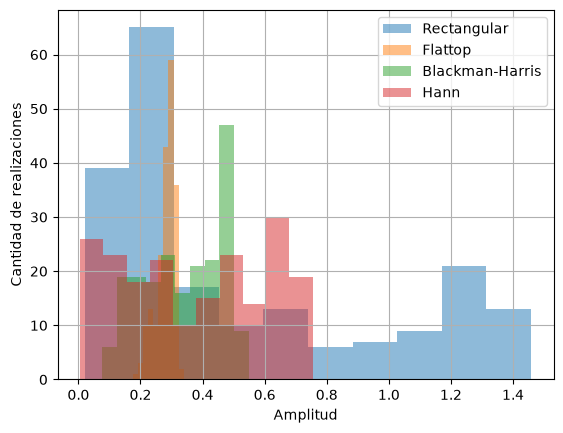

In [119]:
plt.figure()

plt.hist(a1, alpha=0.5, label='Rectangular')
plt.hist(a1_flat, alpha=0.5, label='Flattop')
plt.hist(a1_blackmanharris, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_hann, alpha=0.5, label='Hann')

plt.xlabel('Amplitud')
plt.ylabel('Cantidad de realizaciones')

plt.legend()
plt.grid()
plt.show()

Lo que se observa en este caso es la misma señal analizada anteriormente, pero con una mayor potencia de ruido ya que disminuyo la SNR. Al aumentar el ruido, las componentes aleatorias tienen mayor influencia sobre el espectro y pueden alterar en mayor medida la amplitud y la ubicación del máximo de la FFT. Por este motivo, los estimadores presentan una mayor incertidumbre y sus resultados pueden variar más entre las distintas realizaciones, produciendo una mayor dispersión en los histogramas.

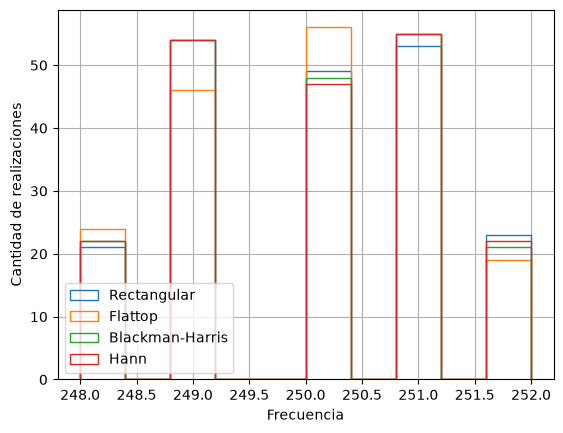

In [120]:
plt.figure()

plt.hist(frec_est, histtype='step', label='Rectangular')
plt.hist(frec_est_flat, histtype='step', label='Flattop')
plt.hist(frec_est_blackmanharris, histtype='step', label='Blackman-Harris')
plt.hist(frec_est_hann, histtype='step', label='Hann')

plt.xlabel('Frecuencia')
plt.ylabel('Cantidad de realizaciones')

plt.legend()
plt.grid()
plt.show()

En la estimación de frecuencia para $SNR=3\,dB$ se observa que las cuatro ventanas continúan presentando resultados muy similares, con valores entre $248$ y $252\,Hz$ y centrados alrededor de $250\,Hz$. Sin embargo, al aumentar la potencia del ruido aparecen pequeñas diferencias en la cantidad de realizaciones asignadas a cada bin, ya que el ruido puede modificar levemente la ubicación del máximo de la FFT y hacer que el estimador seleccione un bin vecino. A pesar de esto, el histograma sigue superpuesto, por lo que el efecto de la ventana sobre la estimación de frecuencia continúa siendo pequeño en comparación con el observado en la estimación de amplitud.

Se repite el cálculo de la esperanza, el sesgo y la varianza del estimador de amplitud para las cuatro ventanas, ahora utilizando $SNR=3\,dB$. Esto permitirá comparar los resultados con el caso de $10\,dB$ y ver si el aumento de la potencia del ruido afecta la exactitud y la dispersión de las estimaciones.

In [121]:
a1_esperanza = np.mean(a1)

sesgo = a1_esperanza - a0

varianza = np.mean((a1 - a1_esperanza)**2)

In [122]:
a1_flat_esperanza = np.mean(a1_flat)

sesgo_flat = a1_flat_esperanza - a0

varianza_flat = np.mean((a1_flat - a1_flat_esperanza)**2)

In [123]:
a1_blackmanharris_esperanza = np.mean(a1_blackmanharris)

sesgo_blackmanharris = a1_blackmanharris_esperanza - a0

varianza_blackmanharris = np.mean((a1_blackmanharris - a1_blackmanharris_esperanza)**2)

In [125]:
frec_esperanza_hann = np.mean(frec_est_hann)

sesgo_frecuencia_hann = np.mean (frec_est_hann - f1)

varianza_frecuencia_hann = np.mean((frec_est_hann - frec_esperanza_hann)**2)

#### Sesgo y varianza del estimador de amplitud

| Ventana | Sesgo | Varianza |
|---|---:|---:|
| Rectangular | -0.8856443708681033 | 0.19588655557603737 |
| Flattop | -1.1328808260498446 | 0.0009412822909681231 |
| Blackman-Harris | -1.072866019821795 | 0.015886595713199052 |
| Hann | -1.0398149491096482 | 0.05431921058817359 |

Los resultados muestran nuevamente diferencias claras entre las ventanas. La ventana rectangular presenta el sesgo de menor magnitud, pero también la mayor varianza, indicando que sus estimaciones se encuentran más dispersas entre las distintas realizaciones. En cambio, Flattop presenta una varianza muy pequeña, por lo que entrega estimaciones mucho más estables, aunque su valor medio se encuentra más alejado de la amplitud real debido a la ganancia propia de la ventana. Blackman-Harris y Hann presentan comportamientos intermedios. Al comparar estos resultados con los obtenidos para $SNR=10\,dB$, se observa que los valores son muy similares, lo que indica que en este experimento el comportamiento del estimador de amplitud depende fuertemente de la ventana utilizada y del desplazamiento de la frecuencia respecto del bin central, mientras que el aumento del ruido produce cambios menores en comparación.

In [128]:
f0 = omega0 * fs / (2*np.pi)
f1 = f0 + f_r * fs/N

In [129]:
frec_esperanza = np.mean(frec_est)

sesgo_frecuencia = np.mean (frec_est - f1)

varianza_frecuencia = np.mean((frec_est - frec_esperanza)**2)

In [130]:
frec_flat_esperanza = np.mean(frec_est_flat)

sesgo_flat_frecuencia = np.mean (frec_est_flat - f1)

varianza_flat_frecuencia = np.mean((frec_est_flat - frec_flat_esperanza)**2)

In [131]:
a1_blackmanharris_esperanza = np.mean(a1_blackmanharris)

sesgo_blackmanharris = a1_blackmanharris_esperanza - a0

varianza_blackmanharris = np.mean((a1_blackmanharris - a1_blackmanharris_esperanza)**2)

In [132]:
frec_esperanza_hann = np.mean(frec_est_hann)

sesgo_frecuencia_hann = np.mean (frec_est_hann - f1)

varianza_frecuencia_hann = np.mean((frec_est_hann - frec_esperanza_hann)**2)

#### Sesgo y varianza del estimador de frecuencia

| Ventana | Sesgo [Hz] | Varianza [Hz²] |
|---|---:|---:|
| Rectangular | 0.02694066972725608 | 1.4147750000000001 |
| Flattop | 0.006940669727256079 | 1.3649750000000003 |
| Blackman-Harris | 0.021940669727256078 | 1.3899000000000001 |
| Hann | 0.01694066972725608 | 1.4249750000000003 |

Los resultados muestran que el estimador de frecuencia presenta un sesgo muy cercano a cero para las cuatro ventanas, indicando que las frecuencias estimadas se encuentran, en promedio, muy próximas a los valores reales. Flattop presenta el menor sesgo en valor absoluto y también la menor varianza, aunque las diferencias respecto de las demás ventanas son pequeñas. Las varianzas se encuentran aproximadamente entre $1.36$ y $1.42\,Hz^2$, lo que confirma el comportamiento similar observado en el histograma. Esto puede explicarse porque el estimador de frecuencia selecciona el bin donde se encuentra el máximo de la FFT y, con una resolución de $\Delta f=1\,Hz$, las distintas ventanas suelen identificar el mismo bin o alguno de sus vecinos. Por lo tanto, el tipo de ventana tiene un efecto mucho menor sobre la estimación de frecuencia que sobre la estimación de amplitud.

### Conclusión

En este trabajo se analizó el comportamiento de los estimadores de amplitud y frecuencia para una señal senoidal con pequeñas variaciones aleatorias de frecuencia y presencia de ruido, utilizando las ventanas rectangular, Flattop, Blackman-Harris y Hann. A partir de los histogramas y del cálculo del sesgo y la varianza se observó que el tipo de ventana tiene una influencia mucho mayor sobre la estimación de amplitud que sobre la de frecuencia. La ventana rectangular presentó la mayor dispersión en amplitud, mientras que Flattop mostró estimaciones mucho más concentradas y, por lo tanto, una varianza considerablemente menor; Blackman-Harris y Hann presentaron comportamientos intermedios. En frecuencia, en cambio, las cuatro ventanas mostraron resultados muy similares, con sesgos cercanos a cero y varianzas próximas entre sí, debido a que el estimador selecciona principalmente el bin donde se encuentra el máximo de la FFT. Al disminuir la SNR de $10\,dB$ a $3\,dB$ aumentó la potencia del ruido y, en consecuencia, la incertidumbre de las estimaciones, aunque se mantuvieron las tendencias generales observadas para cada ventana. De esta manera, el trabajo permitió comprobar cómo la elección de la ventana y el nivel de ruido influyen de distinta forma sobre la precisión y estabilidad de los estimadores de amplitud y frecuencia.